In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('application_test.csv')

#EDA

In [4]:
df.shape

(307511, 20)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   TARGET               307511 non-null  int64  
 1   NAME_CONTRACT_TYPE   307511 non-null  str    
 2   CODE_GENDER          307511 non-null  str    
 3   FLAG_OWN_CAR         307511 non-null  str    
 4   FLAG_OWN_REALTY      307511 non-null  str    
 5   CNT_CHILDREN         307511 non-null  int64  
 6   AMT_INCOME_TOTAL     307511 non-null  float64
 7   AMT_CREDIT           307511 non-null  float64
 8   AMT_ANNUITY          307499 non-null  float64
 9   AMT_GOODS_PRICE      307233 non-null  float64
 10  NAME_INCOME_TYPE     307511 non-null  str    
 11  NAME_EDUCATION_TYPE  307511 non-null  str    
 12  NAME_FAMILY_STATUS   307511 non-null  str    
 13  NAME_HOUSING_TYPE    307511 non-null  str    
 14  OCCUPATION_TYPE      211120 non-null  str    
 15  CNT_FAM_MEMBERS      307509 

In [6]:
df.describe()

,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,CNT_FAM_MEMBERS,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
count,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307509.000000,134133.000000,3.068510e+05,246546.000000
mean,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,2.152665,0.502130,5.143927e-01,0.510853
std,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.910682,0.211062,1.910602e-01,0.194844
min,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,1.000000,0.014568,8.170000e-08,0.000527
25%,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,2.000000,0.334007,3.924574e-01,0.370650
50%,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,2.000000,0.505998,5.659614e-01,0.535276
75%,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,3.000000,0.675053,6.636171e-01,0.669057
max,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,20.000000,0.962693,8.549997e-01,0.896010


In [7]:
df.isnull().sum()

TARGET                      0
NAME_CONTRACT_TYPE          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
AMT_CREDIT                  0
AMT_ANNUITY                12
AMT_GOODS_PRICE           278
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
OCCUPATION_TYPE         96391
CNT_FAM_MEMBERS             2
ORGANIZATION_TYPE           0
EXT_SOURCE_1           173378
EXT_SOURCE_2              660
EXT_SOURCE_3            60965
dtype: int64

In [8]:
print(df['TARGET'].value_counts())
print(df['FLAG_OWN_REALTY'].value_counts())
print(df['FLAG_OWN_CAR'].value_counts())
print(df['CODE_GENDER'].value_counts())
print(df['ORGANIZATION_TYPE'].value_counts())
print(df['NAME_HOUSING_TYPE'].value_counts())
print(df['NAME_FAMILY_STATUS'].value_counts())
print(df['NAME_EDUCATION_TYPE'].value_counts())
print(df['NAME_INCOME_TYPE'].value_counts())
print(df['NAME_CONTRACT_TYPE'].value_counts())

TARGET
0    282686
1     24825
Name: count, dtype: int64
FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64
FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64
ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Industry: type 3           3278
Security                   3247
Housing                    2958
Industry: type 11          2704
Military                   2634
Bank                       2507
Agriculture                2454
Police      

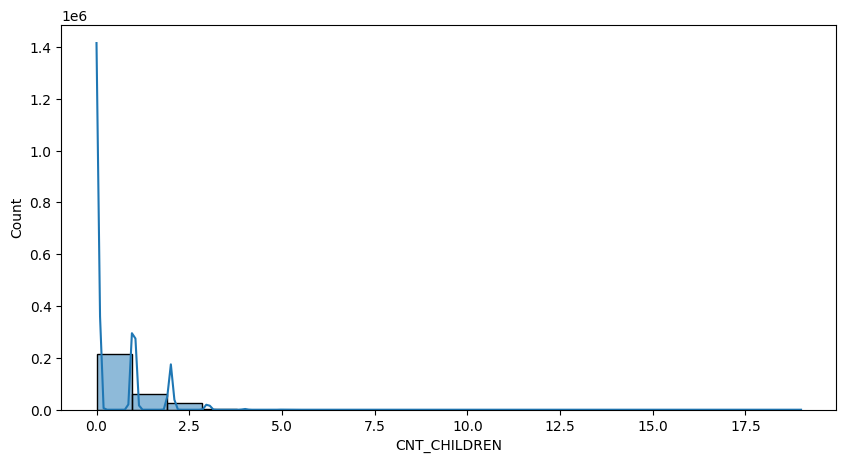

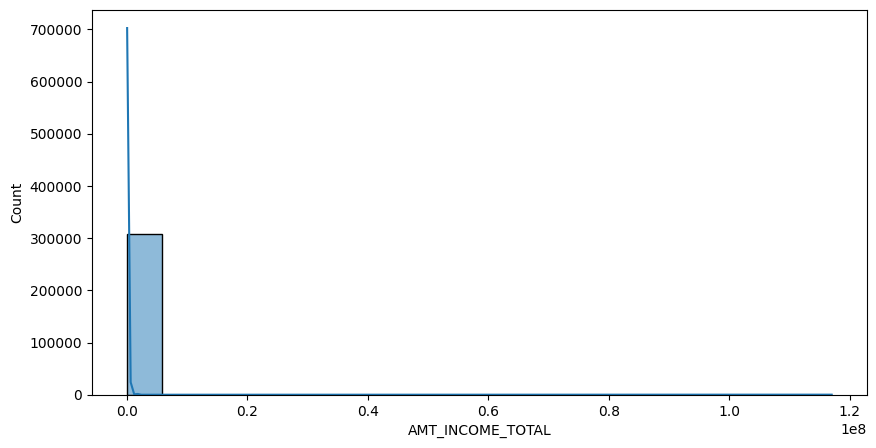

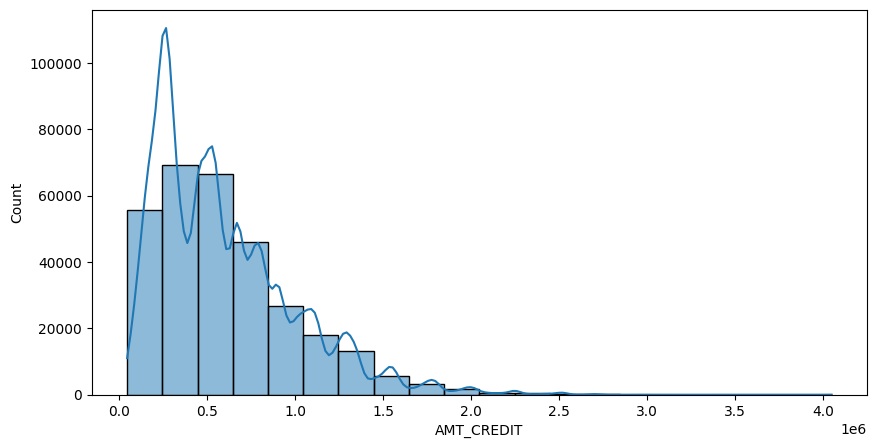

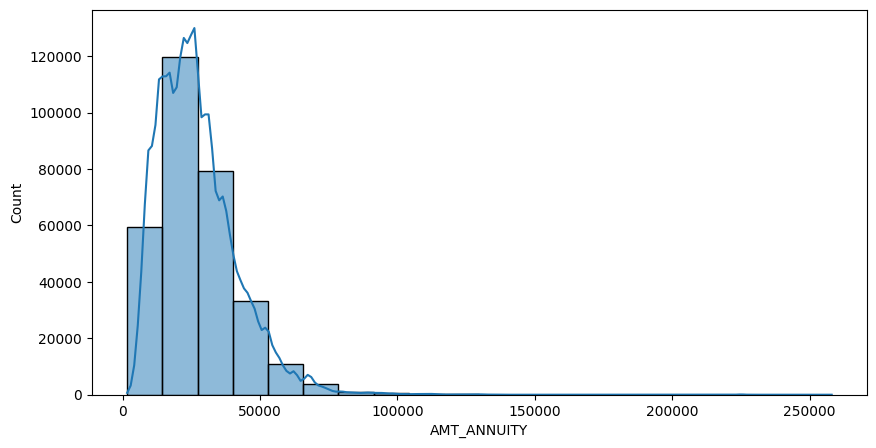

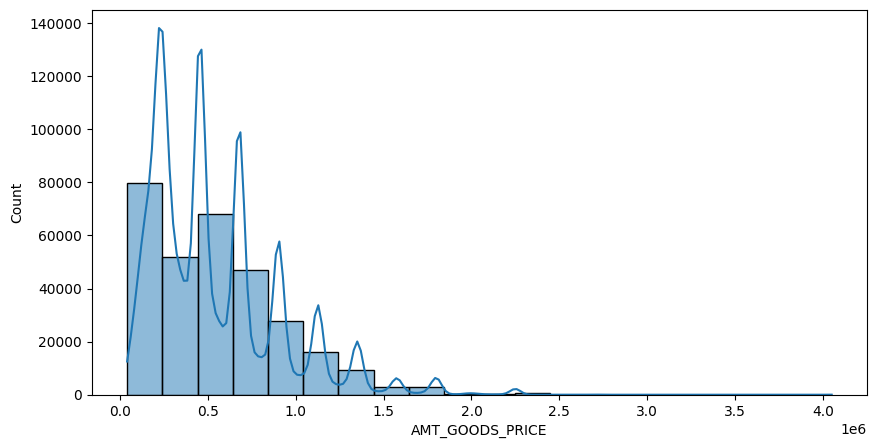

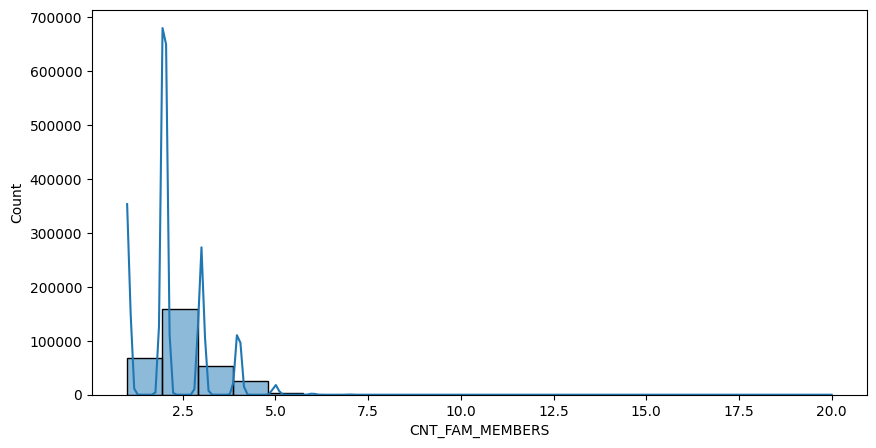

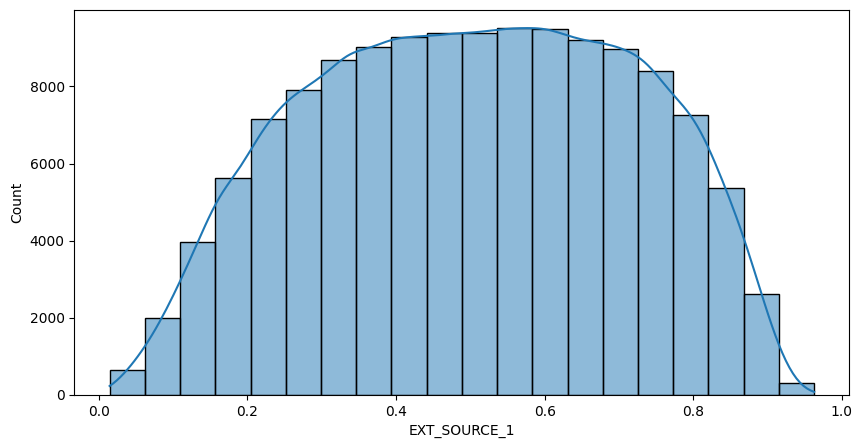

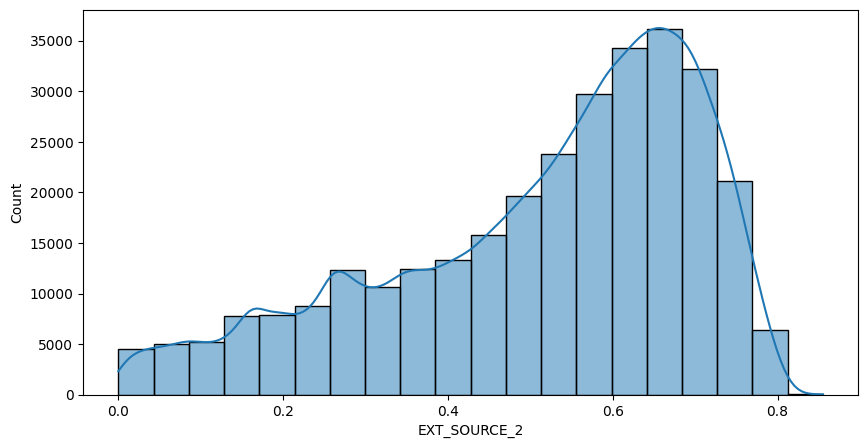

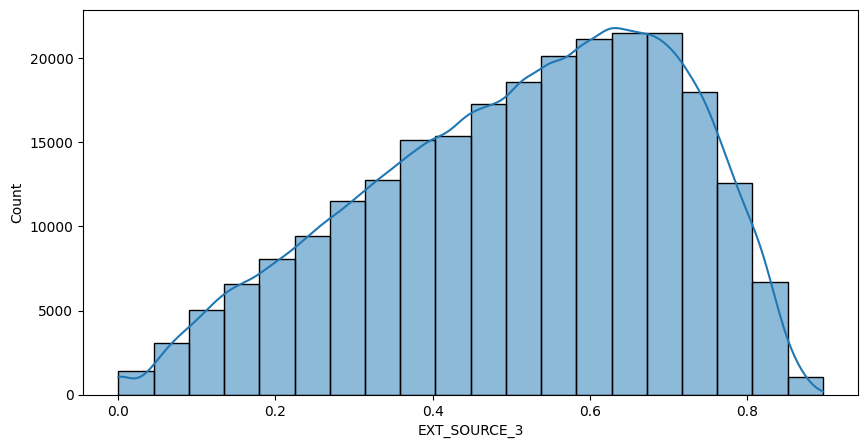

In [9]:
numeric_columns=['CNT_CHILDREN','AMT_INCOME_TOTAL','AMT_CREDIT',"AMT_ANNUITY","AMT_GOODS_PRICE","CNT_FAM_MEMBERS","EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3"]

for col in numeric_columns:
    plt.figure(figsize=(10,5))
    sns.histplot(df[col],kde=True,bins=20)
    plt.show()

<Axes: xlabel='CODE_GENDER', ylabel='count'>

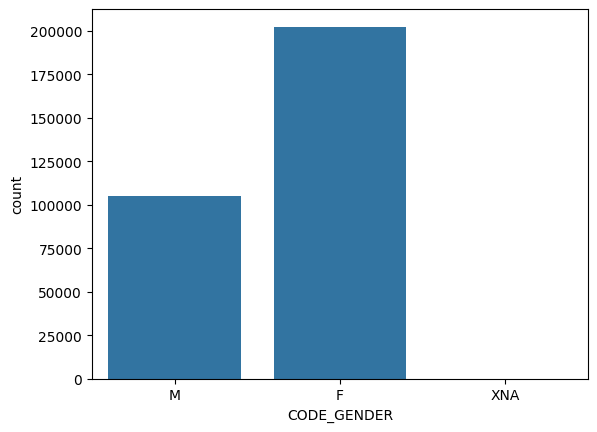

In [10]:
sns.countplot(x=df['CODE_GENDER'])

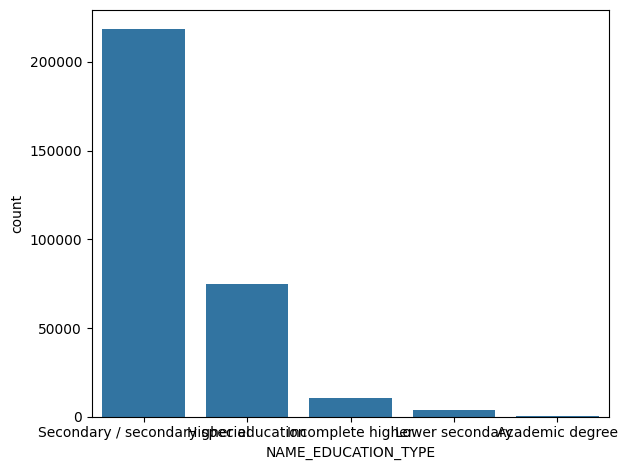

In [11]:
sns.countplot(x=df['NAME_EDUCATION_TYPE'])
plt.tight_layout()

<Axes: xlabel='TARGET', ylabel='count'>

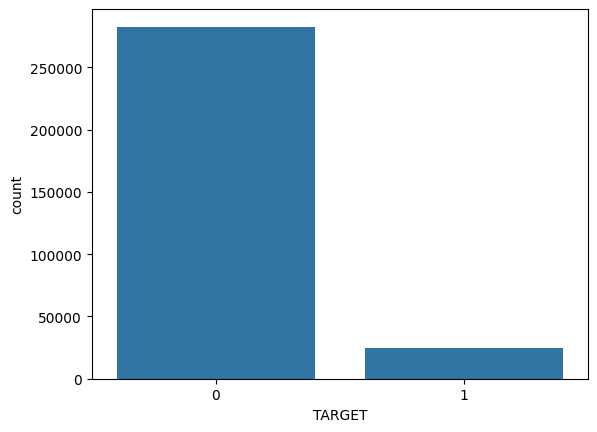

In [12]:
sns.countplot(x=df['TARGET'])

<Axes: xlabel='ORGANIZATION_TYPE', ylabel='count'>

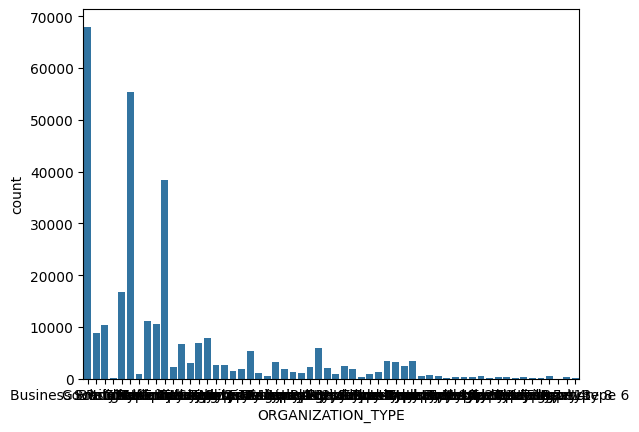

In [13]:
sns.countplot(x=df['ORGANIZATION_TYPE'])

#Data cleaning , Data preprocessing

In [14]:
df.drop(columns=['OCCUPATION_TYPE'], inplace=True)

In [15]:
df['CODE_GENDER'].replace('XNA', df['CODE_GENDER'].mode()[0], inplace=True)

0         M
1         F
2         M
3         F
4         M
         ..
307506    M
307507    F
307508    F
307509    F
307510    F
Name: CODE_GENDER, Length: 307511, dtype: str

In [16]:
df['EXT_SOURCE_1'] = df['EXT_SOURCE_1'].fillna(df['EXT_SOURCE_1'].median())
df['EXT_SOURCE_2'] = df['EXT_SOURCE_2'].fillna(df['EXT_SOURCE_2'].median())
df['EXT_SOURCE_3'] = df['EXT_SOURCE_3'].fillna(df['EXT_SOURCE_3'].median())
df['AMT_ANNUITY'] = df['AMT_ANNUITY'].fillna(df['AMT_ANNUITY'].median())
df['AMT_GOODS_PRICE'] = df['AMT_GOODS_PRICE'].fillna(df['AMT_GOODS_PRICE'].median())
df['CNT_FAM_MEMBERS'] = df['CNT_FAM_MEMBERS'].fillna(df['CNT_FAM_MEMBERS'].median())

print(df.isnull().sum())

TARGET                 0
NAME_CONTRACT_TYPE     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
AMT_CREDIT             0
AMT_ANNUITY            0
AMT_GOODS_PRICE        0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
CNT_FAM_MEMBERS        0
ORGANIZATION_TYPE      0
EXT_SOURCE_1           0
EXT_SOURCE_2           0
EXT_SOURCE_3           0
dtype: int64


In [17]:
df['CNT_CHILDREN'] = df['CNT_CHILDREN'].clip(upper=5)
df['CNT_FAM_MEMBERS'] = df['CNT_FAM_MEMBERS'].clip(upper=7)

In [18]:
cap = df['AMT_INCOME_TOTAL'].quantile(0.99)
df['AMT_INCOME_TOTAL'] = df['AMT_INCOME_TOTAL'].clip(upper=cap)

In [19]:
mode_val = df['NAME_FAMILY_STATUS'].mode()[0]
df['NAME_FAMILY_STATUS'] = df['NAME_FAMILY_STATUS'].replace('Unknown', mode_val)
print(df['NAME_FAMILY_STATUS'].value_counts())

NAME_FAMILY_STATUS
Married                 196434
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Name: count, dtype: int64


In [20]:
df['ORGANIZATION_TYPE'] = df['ORGANIZATION_TYPE'].apply(
    lambda x: x.split(':')[0].strip() if ':' in x else x
)
df['ORGANIZATION_TYPE'] = df['ORGANIZATION_TYPE'].apply(
    lambda x: x.split(' Type')[0].strip() if ' Type' in x else x
)
print(df['ORGANIZATION_TYPE'].value_counts())

ORGANIZATION_TYPE
Business Entity        84529
XNA                    55374
Self-employed          38412
Other                  16683
Trade                  14315
Industry               14311
Medicine               11193
Government             10404
Transport               8990
School                  8893
Kindergarten            6880
Construction            6721
Security                3247
Housing                 2958
Military                2634
Bank                    2507
Agriculture             2454
Police                  2341
Postal                  2157
Security Ministries     1974
Restaurant              1811
Services                1575
University              1327
Hotel                    966
Electricity              950
Insurance                597
Telecom                  577
Emergency                560
Advertising              429
Realtor                  396
Culture                  379
Mobile                   317
Legal Services           305
Cleaning                 

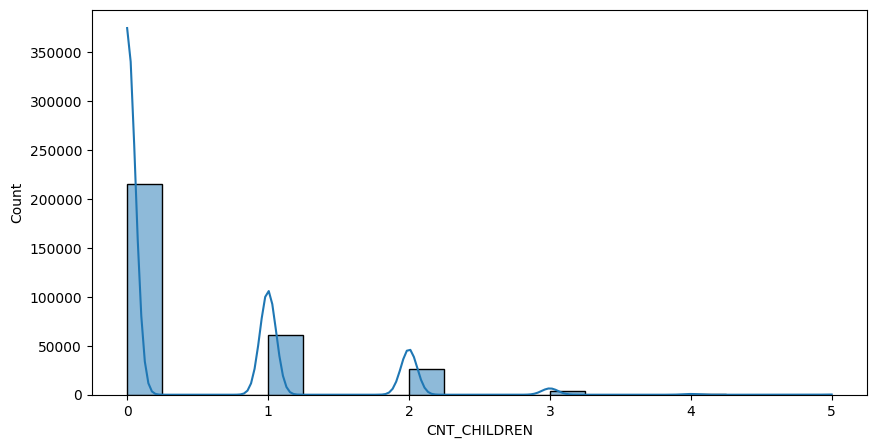

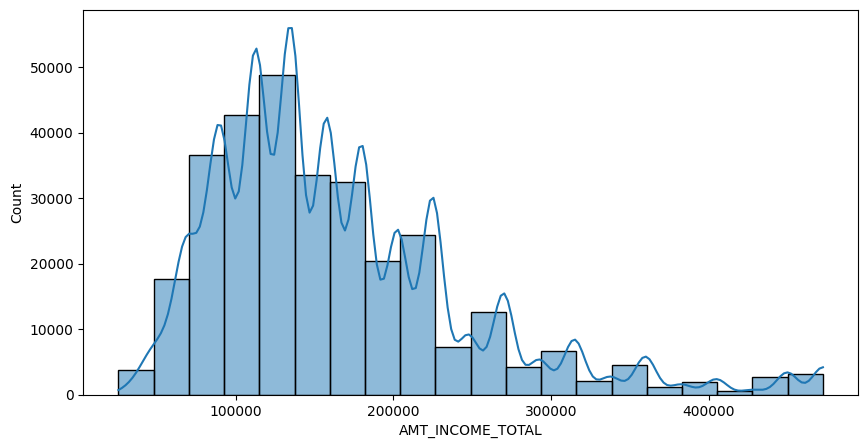

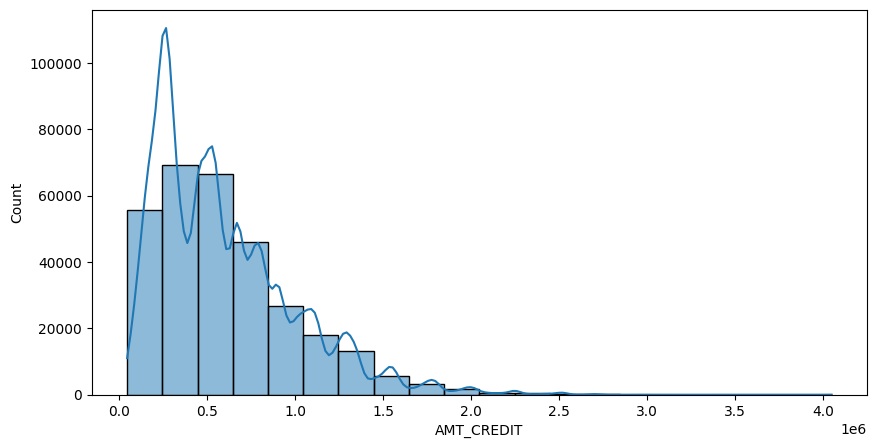

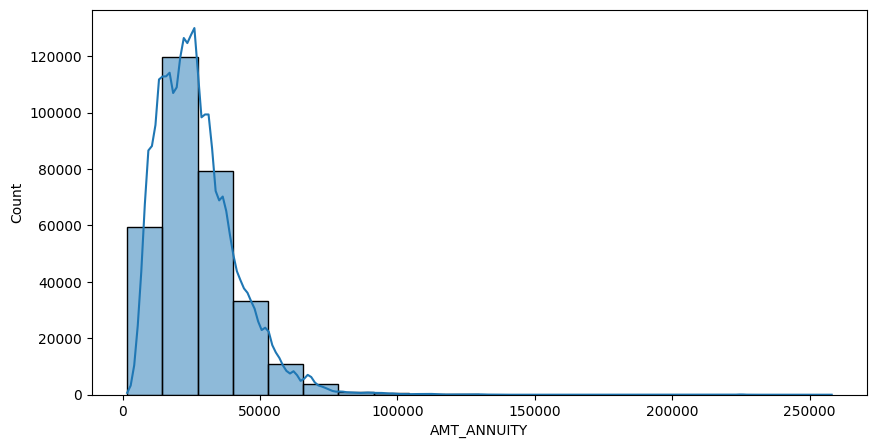

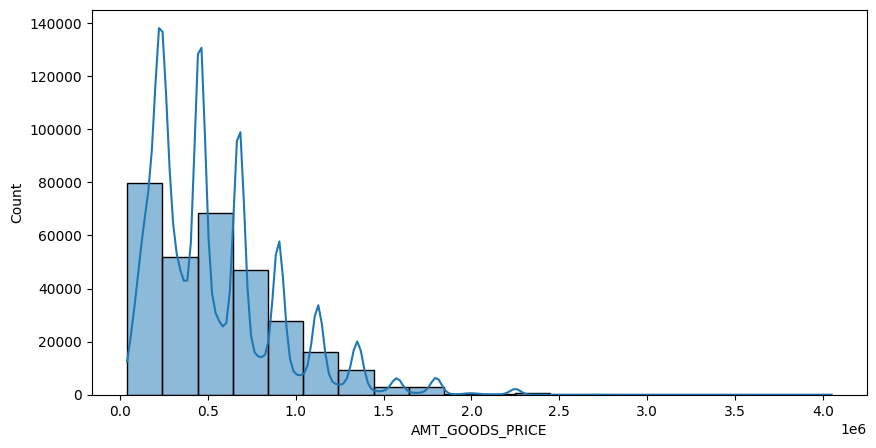

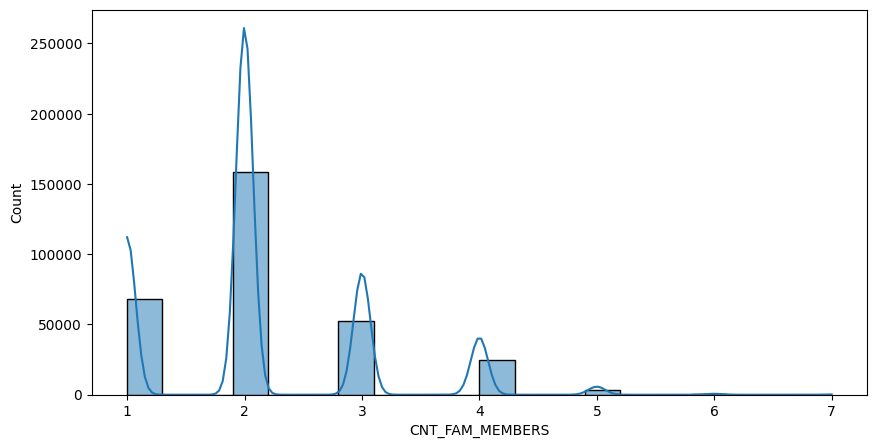

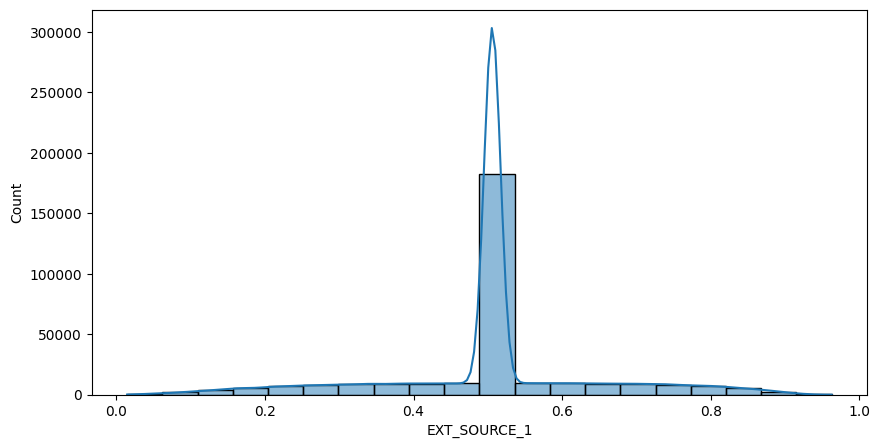

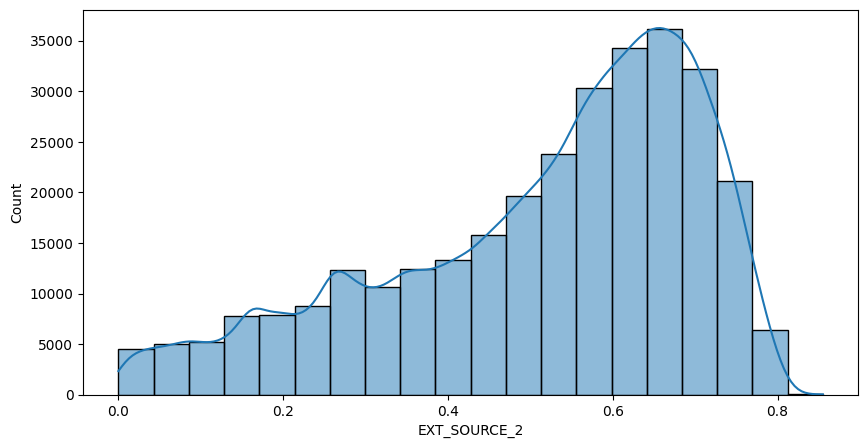

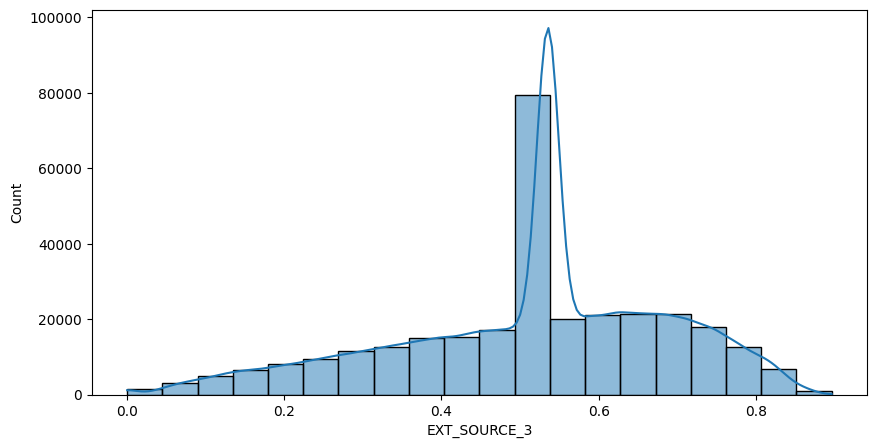

In [21]:
numeric_columns2=['CNT_CHILDREN','AMT_INCOME_TOTAL','AMT_CREDIT',"AMT_ANNUITY","AMT_GOODS_PRICE","CNT_FAM_MEMBERS","EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3"]

for col in numeric_columns2:
    plt.figure(figsize=(10,5))
    sns.histplot(df[col],kde=True,bins=20)
    plt.show()

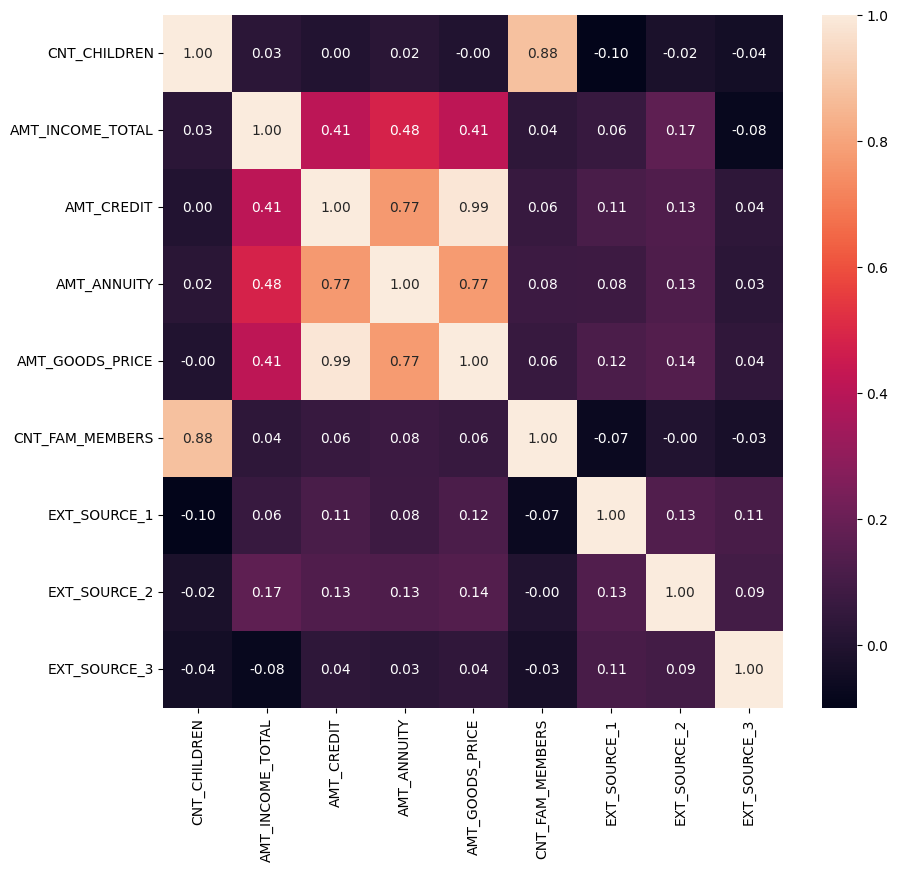

In [22]:
plt.figure(figsize=(10, 9))
sns.heatmap(df[numeric_columns2].corr(), annot=True, fmt='.2f')
plt.show()

In [50]:
# Save clean data before scaling and encoding
df.to_csv('loan_clean_data.csv', index=False)
print('Clean data saved:', df.shape)

Clean data saved: (307511, 73)


#Feature Engineering

In [23]:
from scipy.stats import pearsonr, chi2_contingency

In [24]:
numeric_features = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
                    'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

pearson_results = {}
for col in numeric_features:
    corr, p_val = pearsonr(df[col], df['TARGET'])
    decision = 'reject null (keep feature)' if p_val < 0.05 else 'accept null (drop feature)'
    pearson_results[col] = {
        'correlation': round(corr, 4),
        'p_value': round(p_val, 6),
        'decision': decision
    }

pearson_df = pd.DataFrame(pearson_results).T
pearson_df = pearson_df.sort_values(by='p_value')
print("── Pearson Correlation Results ──")
print(pearson_df)

── Pearson Correlation Results ──
                 correlation p_value                    decision
AMT_INCOME_TOTAL     -0.0233     0.0  reject null (keep feature)
AMT_CREDIT           -0.0304     0.0  reject null (keep feature)
AMT_ANNUITY          -0.0128     0.0  reject null (keep feature)
AMT_GOODS_PRICE      -0.0396     0.0  reject null (keep feature)
CNT_CHILDREN          0.0192     0.0  reject null (keep feature)
CNT_FAM_MEMBERS       0.0092     0.0  reject null (keep feature)
EXT_SOURCE_1         -0.0989     0.0  reject null (keep feature)
EXT_SOURCE_2         -0.1603     0.0  reject null (keep feature)
EXT_SOURCE_3         -0.1559     0.0  reject null (keep feature)


In [25]:
cat_features = [col for col in df.columns if col not in 
                ['TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 
                 'AMT_GOODS_PRICE', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 
                 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']]

alpha = 0.05
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df[col], df['TARGET'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'reject null (keep feature)' if p_val < alpha else 'accept null (drop feature)'
    chi2_results[col] = {
        'chi2_statistic': round(chi2_stat, 4),
        'p_value': round(p_val, 6),
        'decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
print("── Chi-Square Test Results ──")
print(chi2_df)

── Chi-Square Test Results ──
                    chi2_statistic   p_value                    decision
NAME_CONTRACT_TYPE        293.1505       0.0  reject null (keep feature)
CODE_GENDER               920.7913       0.0  reject null (keep feature)
FLAG_OWN_CAR               146.656       0.0  reject null (keep feature)
NAME_INCOME_TYPE         1253.4708       0.0  reject null (keep feature)
NAME_EDUCATION_TYPE      1019.2132       0.0  reject null (keep feature)
NAME_FAMILY_STATUS        504.5401       0.0  reject null (keep feature)
NAME_HOUSING_TYPE         420.5562       0.0  reject null (keep feature)
ORGANIZATION_TYPE        1409.4752       0.0  reject null (keep feature)
FLAG_OWN_REALTY            11.5758  0.000668  reject null (keep feature)


In [26]:
cols_to_drop = chi2_df[chi2_df['decision'] == 'accept null (drop feature)'].index.tolist()
df = df.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns")
print(f"Remaining shape: {df.shape}")

Dropped 0 columns
Remaining shape: (307511, 19)


#Feature Selection & Preprocessing

In [27]:
df = pd.get_dummies(df, columns=['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 
                                  'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 
                                  'ORGANIZATION_TYPE'], drop_first=False)

print(df.shape)
print(df.head())

(307511, 73)
   TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  \
0       1         Cash loans           M            N               Y   
1       0         Cash loans           F            N               N   
2       0    Revolving loans           M            Y               Y   
3       0         Cash loans           F            N               Y   
4       0         Cash loans           M            N               Y   

   CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE  \
0             0          202500.0    406597.5      24700.5         351000.0   
1             0          270000.0   1293502.5      35698.5        1129500.0   
2             0           67500.0    135000.0       6750.0         135000.0   
3             0          135000.0    312682.5      29686.5         297000.0   
4             0          121500.0    513000.0      21865.5         513000.0   

   ...  ORGANIZATION_TYPE_School  ORGANIZATION_TYPE_Security  \
0  ...   

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Encoding done")
print(df.head())

Encoding done
   TARGET  NAME_CONTRACT_TYPE  CODE_GENDER  FLAG_OWN_CAR  FLAG_OWN_REALTY  \
0       1                   0            1             0                1   
1       0                   0            0             0                0   
2       0                   1            1             1                1   
3       0                   0            0             0                1   
4       0                   0            1             0                1   

   CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE  \
0             0          202500.0    406597.5      24700.5         351000.0   
1             0          270000.0   1293502.5      35698.5        1129500.0   
2             0           67500.0    135000.0       6750.0         135000.0   
3             0          135000.0    312682.5      29686.5         297000.0   
4             0          121500.0    513000.0      21865.5         513000.0   

   ...  ORGANIZATION_TYPE_School  ORGANIZATION_T

In [29]:
from sklearn.model_selection import train_test_split

X = df.drop('TARGET', axis=1)
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts())

(246008, 72) (61503, 72)
TARGET
0    226148
1     19860
Name: count, dtype: int64


In [30]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("After SMOTE:")
print(y_train_sm.value_counts())

After SMOTE:
TARGET
0    226148
1    226148
Name: count, dtype: int64


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols_to_scale = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
                 'AMT_GOODS_PRICE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
cols_to_scale = [c for c in cols_to_scale if c in X_train_sm.columns]

X_train_sm[cols_to_scale] = scaler.fit_transform(X_train_sm[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Align columns
X_test = X_test.reindex(columns=X_train_sm.columns, fill_value=0)

print("Scaling done")

Scaling done


#Model Training

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_sm, y_train_sm)

y_prob_lr = lr.predict_proba(X_test)[:,1]
y_pred_lr = (y_prob_lr >= 0.3).astype(int)

print('\n── Logistic Regression ──')
print(classification_report(y_test, y_pred_lr))
print('Accuracy:', round(accuracy_score(y_test, y_pred_lr), 4))
print('AUC-ROC:', round(roc_auc_score(y_test, y_prob_lr), 4))


── Logistic Regression ──
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     56538
           1       0.33      0.14      0.20      4965

    accuracy                           0.91     61503
   macro avg       0.63      0.56      0.57     61503
weighted avg       0.88      0.91      0.89     61503

Accuracy: 0.9076
AUC-ROC: 0.7343


In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sm, y_train_sm)

y_prob_knn = knn.predict_proba(X_test)[:,1]
y_pred_knn = (y_prob_knn >= 0.3).astype(int)

print('\n── KNN Classifier ──')
print(classification_report(y_test, y_pred_knn))
print('Accuracy:', round(accuracy_score(y_test, y_pred_knn), 4))
print('AUC-ROC:', round(roc_auc_score(y_test, y_prob_knn), 4))


── KNN Classifier ──
              precision    recall  f1-score   support

           0       0.93      0.89      0.91     56538
           1       0.16      0.25      0.20      4965

    accuracy                           0.84     61503
   macro avg       0.55      0.57      0.55     61503
weighted avg       0.87      0.84      0.85     61503

Accuracy: 0.8357
AUC-ROC: 0.609


In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_train_sm, y_train_sm)

y_prob_rf = rf.predict_proba(X_test)[:,1]
y_pred_rf = (y_prob_rf >= 0.3).astype(int)

print('\n── Random Forest ──')
print(classification_report(y_test, y_pred_rf))
print('Accuracy:', round(accuracy_score(y_test, y_pred_rf), 4))
print('AUC-ROC:', round(roc_auc_score(y_test, y_prob_rf), 4))


── Random Forest ──
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     56538
           1       0.22      0.20      0.21      4965

    accuracy                           0.88     61503
   macro avg       0.57      0.57      0.57     61503
weighted avg       0.87      0.88      0.88     61503

Accuracy: 0.8787
AUC-ROC: 0.6906


In [35]:
from xgboost import XGBClassifier

scale_pos = (y_train_sm == 0).sum() / (y_train_sm == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_sm, y_train_sm)

y_prob_xgb = xgb.predict_proba(X_test)[:,1]
y_pred_xgb = (y_prob_xgb >= 0.3).astype(int)

print('\n── XGBoost ──')
print(classification_report(y_test, y_pred_xgb))
print('Accuracy:', round(accuracy_score(y_test, y_pred_xgb), 4))
print('AUC-ROC:', round(roc_auc_score(y_test, y_prob_xgb), 4))


── XGBoost ──
              precision    recall  f1-score   support

           0       0.93      0.91      0.92     56538
           1       0.19      0.25      0.22      4965

    accuracy                           0.85     61503
   macro avg       0.56      0.58      0.57     61503
weighted avg       0.87      0.85      0.86     61503

Accuracy: 0.8541
AUC-ROC: 0.7017


In [36]:
import pandas as pd

results = {
    'Model': ['Logistic Regression', 'KNN', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_lr), 4),
        round(accuracy_score(y_test, y_pred_knn), 4),
        round(accuracy_score(y_test, y_pred_rf), 4),
        round(accuracy_score(y_test, y_pred_xgb), 4)
    ],
    'AUC-ROC': [
        round(roc_auc_score(y_test, y_prob_lr), 4),
        round(roc_auc_score(y_test, y_prob_knn), 4),
        round(roc_auc_score(y_test, y_prob_rf), 4),
        round(roc_auc_score(y_test, y_prob_xgb), 4)
    ]
}

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  AUC-ROC
0  Logistic Regression    0.9076   0.7343
1                  KNN    0.8357   0.6090
2        Random Forest    0.8787   0.6906
3              XGBoost    0.8541   0.7017


In [37]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_xgb)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f'Optimal Threshold: {round(best_threshold, 4)}')
print(f'Best F1 at this threshold: {round(f1_scores[best_idx], 4)}')

y_pred_xgb_opt = (y_prob_xgb >= best_threshold).astype(int)
print('\n── XGBoost (Optimal Threshold) ──')
print(classification_report(y_test, y_pred_xgb_opt))
print('AUC-ROC:', round(roc_auc_score(y_test, y_prob_xgb), 4))

Optimal Threshold: 0.21250000596046448
Best F1 at this threshold: 0.2436

── XGBoost (Optimal Threshold) ──
              precision    recall  f1-score   support

           0       0.94      0.80      0.86     56538
           1       0.17      0.46      0.24      4965

    accuracy                           0.77     61503
   macro avg       0.55      0.63      0.55     61503
weighted avg       0.88      0.77      0.81     61503

AUC-ROC: 0.7017


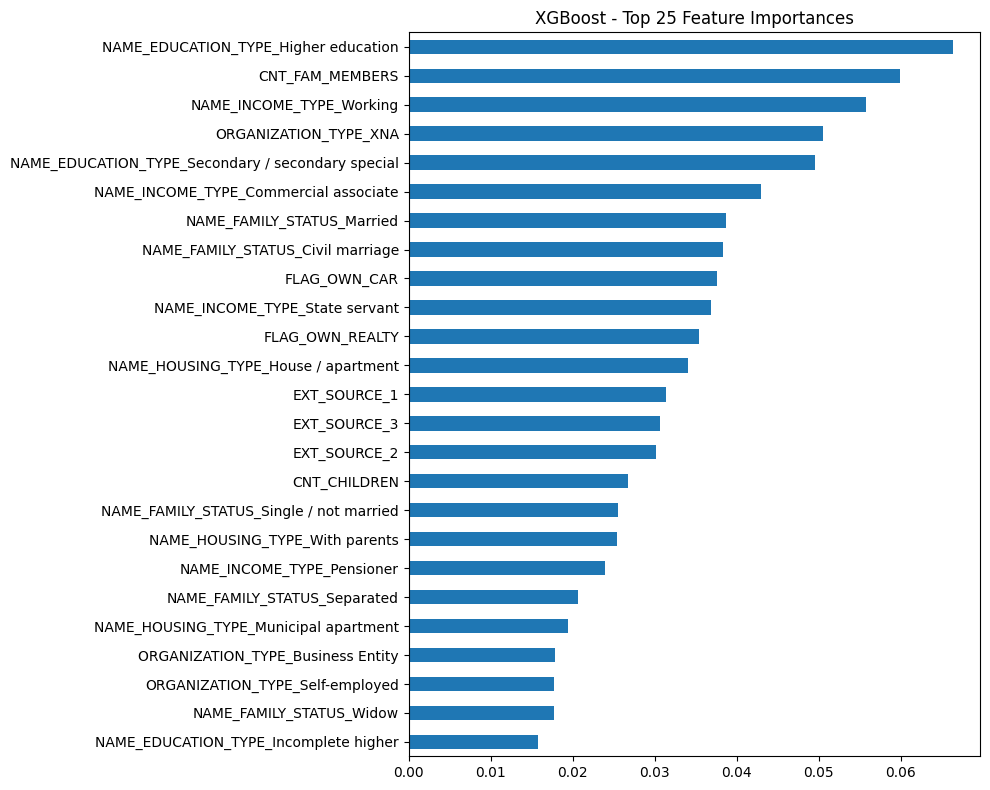


Top 25 Features:
NAME_EDUCATION_TYPE_Higher education                 0.066327
CNT_FAM_MEMBERS                                      0.059896
NAME_INCOME_TYPE_Working                             0.055721
ORGANIZATION_TYPE_XNA                                0.050550
NAME_EDUCATION_TYPE_Secondary / secondary special    0.049535
NAME_INCOME_TYPE_Commercial associate                0.042940
NAME_FAMILY_STATUS_Married                           0.038730
NAME_FAMILY_STATUS_Civil marriage                    0.038356
FLAG_OWN_CAR                                         0.037578
NAME_INCOME_TYPE_State servant                       0.036890
FLAG_OWN_REALTY                                      0.035402
NAME_HOUSING_TYPE_House / apartment                  0.033990
EXT_SOURCE_1                                         0.031401
EXT_SOURCE_3                                         0.030609
EXT_SOURCE_2                                         0.030130
CNT_CHILDREN                                        

In [38]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(xgb.feature_importances_, index=X_train_sm.columns)
top25 = feat_imp.sort_values(ascending=False).head(25)

plt.figure(figsize=(10, 8))
top25.sort_values().plot(kind='barh')
plt.title('XGBoost - Top 25 Feature Importances')
plt.tight_layout()
plt.show()

print('\nTop 25 Features:')
print(top25)

In [39]:
X_train_ns = X_train.copy()
X_test_ns = X_test.copy()

cols_to_scale_ns = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
                    'AMT_GOODS_PRICE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
cols_to_scale_ns = [c for c in cols_to_scale_ns if c in X_train_ns.columns]

scaler_ns = StandardScaler()
X_train_ns[cols_to_scale_ns] = scaler_ns.fit_transform(X_train_ns[cols_to_scale_ns])
X_test_ns[cols_to_scale_ns]  = scaler_ns.transform(X_test_ns[cols_to_scale_ns])
X_test_ns = X_test_ns.reindex(columns=X_train_ns.columns, fill_value=0)

scale_pos_ns = (y_train == 0).sum() / (y_train == 1).sum()

xgb_ns = XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    scale_pos_weight=scale_pos_ns, eval_metric='logloss',
    random_state=42, n_jobs=-1)
xgb_ns.fit(X_train_ns, y_train)

y_prob_xgb_ns = xgb_ns.predict_proba(X_test_ns)[:, 1]
y_pred_xgb_ns = (y_prob_xgb_ns >= best_threshold).astype(int)

print('\n── XGBoost (No SMOTE, scale_pos_weight only) ──')
print(classification_report(y_test, y_pred_xgb_ns))
print('AUC-ROC:', round(roc_auc_score(y_test, y_prob_xgb_ns), 4))


── XGBoost (No SMOTE, scale_pos_weight only) ──
              precision    recall  f1-score   support

           0       0.97      0.21      0.35     56538
           1       0.09      0.93      0.17      4965

    accuracy                           0.27     61503
   macro avg       0.53      0.57      0.26     61503
weighted avg       0.90      0.27      0.34     61503

AUC-ROC: 0.6845


In [40]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

rs = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

rs.fit(X_train_sm, y_train_sm)

print('Best Params:', rs.best_params_)
print('Best CV AUC:', round(rs.best_score_, 4))

y_prob_rs = rs.best_estimator_.predict_proba(X_test)[:, 1]
y_pred_rs = (y_prob_rs >= best_threshold).astype(int)

print('\n── XGBoost (RandomizedSearch Best) ──')
print(classification_report(y_test, y_pred_rs))
print('AUC-ROC:', round(roc_auc_score(y_test, y_prob_rs), 4))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV AUC: 0.9659

── XGBoost (RandomizedSearch Best) ──
              precision    recall  f1-score   support

           0       0.94      0.85      0.89     56538
           1       0.19      0.40      0.25      4965

    accuracy                           0.81     61503
   macro avg       0.56      0.62      0.57     61503
weighted avg       0.88      0.81      0.84     61503

AUC-ROC: 0.7138


In [41]:
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.over_sampling import SMOTE

pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.7, min_child_weight=3,
        reg_alpha=0.1, reg_lambda=1.5,
        scale_pos_weight=scale_pos, eval_metric='logloss',
        random_state=42, n_jobs=-1))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')

print(f'CV AUC per fold: {scores.round(4)}')
print(f'Mean CV AUC: {round(scores.mean(), 4)}')

CV AUC per fold: [0.6936 0.6997 0.6963 0.6935 0.7012]
Mean CV AUC: 0.6968


In [43]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, f1_score

# Final evaluation on test set
pipe.fit(X_train, y_train)

y_prob_final = pipe.predict_proba(X_test)[:, 1]
y_pred_final = (y_prob_final >= best_threshold).astype(int)

print('── Final Model (Pipeline + SMOTE inside CV) ──')
print(classification_report(y_test, y_pred_final))
print('Accuracy :', round(accuracy_score(y_test, y_pred_final), 4))
print('AUC-ROC  :', round(roc_auc_score(y_test, y_prob_final), 4))
print('F1-Default:', round(f1_score(y_test, y_pred_final, pos_label=1), 4))

── Final Model (Pipeline + SMOTE inside CV) ──
              precision    recall  f1-score   support

           0       0.95      0.67      0.79     56538
           1       0.14      0.61      0.23      4965

    accuracy                           0.66     61503
   macro avg       0.55      0.64      0.51     61503
weighted avg       0.89      0.66      0.74     61503

Accuracy : 0.664
AUC-ROC  : 0.6906
F1-Default: 0.2278


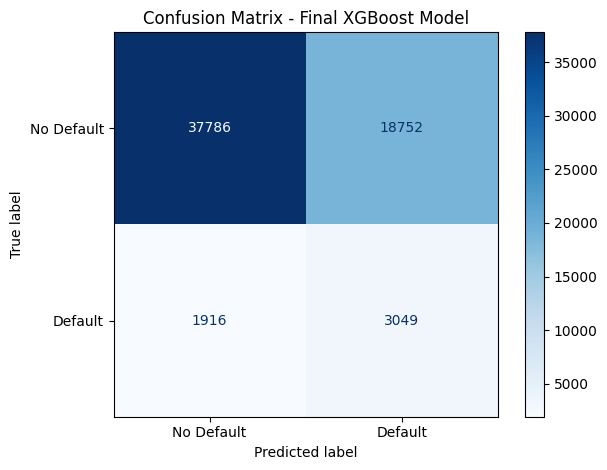

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Final XGBoost Model')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

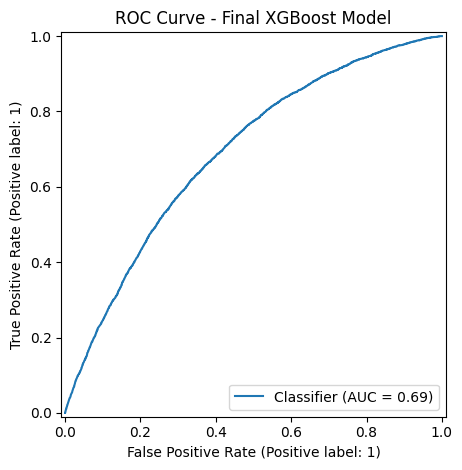

In [45]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob_final)
plt.title('ROC Curve - Final XGBoost Model')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

In [46]:
print('='*65)
print('           COMPLETE MODEL COMPARISON (After All Improvements)')
print('='*65)
comparison = pd.DataFrame({
    'Model': ['XGBoost (baseline)', 'XGBoost+SMOTE+Threshold', 'XGBoost+Pipeline+CV'],
    'AUC-ROC': [0.7512, 0.7017, 0.6906],
    'Class1-Recall': [0.91, 0.46, 0.61],
    'Class1-F1': [0.19, 0.24, 0.23],
    'Overfit': ['Yes (CV gap large)', 'Yes (CV gap large)', 'No (CV≈Test)']
})
print(comparison.to_string(index=False))
print('='*65)

           COMPLETE MODEL COMPARISON (After All Improvements)
                  Model  AUC-ROC  Class1-Recall  Class1-F1            Overfit
     XGBoost (baseline)   0.7512           0.91       0.19 Yes (CV gap large)
XGBoost+SMOTE+Threshold   0.7017           0.46       0.24 Yes (CV gap large)
    XGBoost+Pipeline+CV   0.6906           0.61       0.23       No (CV≈Test)


In [49]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, f1_score

# ── Load raw test file ──
df_raw = pd.read_csv('application_test.csv')

# ── Same cleaning as training ──
df_raw.drop(columns=['OCCUPATION_TYPE'], inplace=True, errors='ignore')
df_raw['CODE_GENDER'].replace('XNA', df_raw['CODE_GENDER'].mode()[0], inplace=True)

df_raw['EXT_SOURCE_1']    = df_raw['EXT_SOURCE_1'].fillna(df_raw['EXT_SOURCE_1'].median())
df_raw['EXT_SOURCE_2']    = df_raw['EXT_SOURCE_2'].fillna(df_raw['EXT_SOURCE_2'].median())
df_raw['EXT_SOURCE_3']    = df_raw['EXT_SOURCE_3'].fillna(df_raw['EXT_SOURCE_3'].median())
df_raw['AMT_ANNUITY']     = df_raw['AMT_ANNUITY'].fillna(df_raw['AMT_ANNUITY'].median())
df_raw['AMT_GOODS_PRICE'] = df_raw['AMT_GOODS_PRICE'].fillna(df_raw['AMT_GOODS_PRICE'].median())
df_raw['CNT_FAM_MEMBERS'] = df_raw['CNT_FAM_MEMBERS'].fillna(df_raw['CNT_FAM_MEMBERS'].median())

df_raw['CNT_CHILDREN']    = df_raw['CNT_CHILDREN'].clip(upper=5)
df_raw['CNT_FAM_MEMBERS'] = df_raw['CNT_FAM_MEMBERS'].clip(upper=7)

cap = df_raw['AMT_INCOME_TOTAL'].quantile(0.99)
df_raw['AMT_INCOME_TOTAL'] = df_raw['AMT_INCOME_TOTAL'].clip(upper=cap)

mode_val = df_raw['NAME_FAMILY_STATUS'].mode()[0]
df_raw['NAME_FAMILY_STATUS'] = df_raw['NAME_FAMILY_STATUS'].replace('Unknown', mode_val)

df_raw['ORGANIZATION_TYPE'] = df_raw['ORGANIZATION_TYPE'].apply(
    lambda x: x.split(':')[0].strip() if ':' in x else x)
df_raw['ORGANIZATION_TYPE'] = df_raw['ORGANIZATION_TYPE'].apply(
    lambda x: x.split(' Type')[0].strip() if ' Type' in x else x)

# ── Drop same chi2 cols that were dropped in training ──
df_raw = df_raw.drop(columns=cols_to_drop, errors='ignore')

# ── Same encoding ──
df_raw = pd.get_dummies(df_raw, columns=['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
                                          'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
                                          'ORGANIZATION_TYPE'], drop_first=False)

from sklearn.preprocessing import LabelEncoder
le2 = LabelEncoder()
cat_cols_raw = df_raw.select_dtypes(include='object').columns.tolist()
for col in cat_cols_raw:
    df_raw[col] = le2.fit_transform(df_raw[col].astype(str))

# ── Align columns to training ──
X_raw = df_raw.reindex(columns=X_train.columns, fill_value=0)

# ── Predict ──
y_prob_raw = pipe.predict_proba(X_raw)[:, 1]
y_pred_raw = (y_prob_raw >= best_threshold).astype(int)

# ── Summary ──
print(f'Total Records       : {len(X_raw)}')
print(f'Predicted Default   : {y_pred_raw.sum()} ({round(y_pred_raw.mean()*100, 2)}%)')
print(f'Predicted No Default: {(y_pred_raw==0).sum()} ({round((y_pred_raw==0).mean()*100, 2)}%)')

# ── Save predictions ──
df_raw['DEFAULT_PROBABILITY'] = y_prob_raw.round(4)
df_raw['PREDICTED_DEFAULT']   = y_pred_raw
df_raw.to_csv('loan_predictions_final.csv', index=False)
print('\nPredictions saved to loan_predictions_final.csv')

Total Records       : 307511
Predicted Default   : 71926 (23.39%)
Predicted No Default: 235585 (76.61%)

Predictions saved to loan_predictions_final.csv


In [51]:
import joblib

joblib.dump(xgb, 'loan_default_xgboost_model.pkl')
print('Model saved.')

Model saved.
